In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\jenef\OneDrive\Desktop\DataScience Project\Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Shape of Dataset:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nStatistical Summary:")
df.describe()

Shape of Dataset: (891, 12)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


             Missing Values  Percentage
PassengerId               0    0.000000
Survived                  0    0.000000
Pclass                    0    0.000000
Name                      0    0.000000
Sex                       0    0.000000
Age                     177   19.865320
SibSp                     0    0.000000
Parch                     0    0.000000
Ticket                    0    0.000000
Fare                      0    0.000000
Cabin                   687   77.104377
Embarked                  2    0.224467


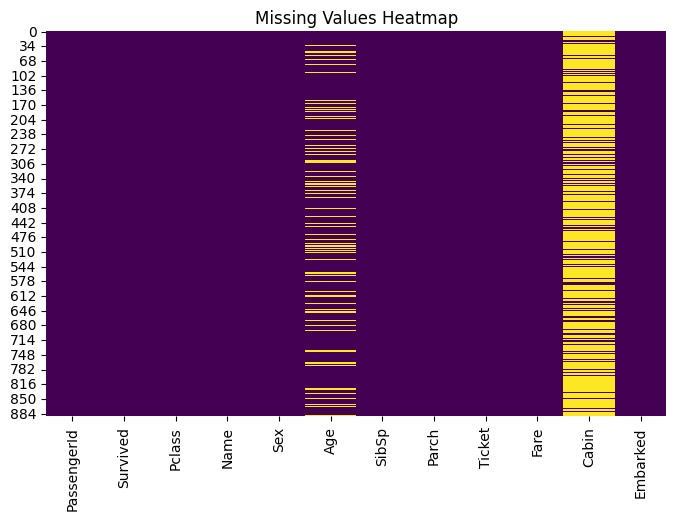

In [5]:
# Missing values count
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})

print(missing_df)

# Visualize missing values
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

C:\Users\jenef\AppData\Local\Temp\ipykernel_28992\2291008666.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


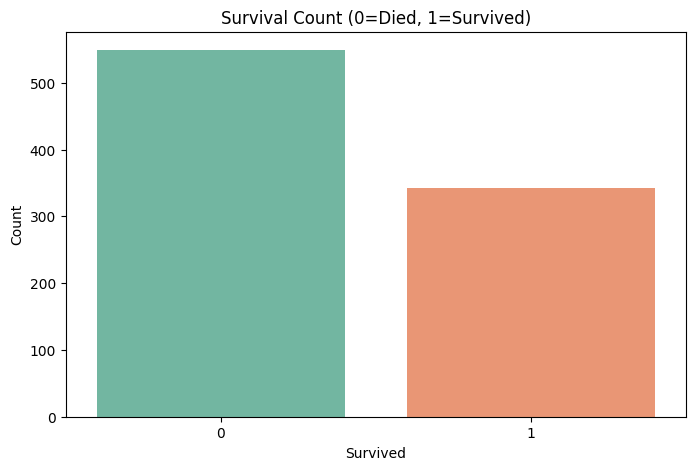

Survival Rate:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [6]:
# Survival count
plt.figure(figsize=(8,5))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Survival Count (0=Died, 1=Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

# Survival percentage
print("Survival Rate:")
print(df['Survived'].value_counts(normalize=True) * 100)

C:\Users\jenef\AppData\Local\Temp\ipykernel_28992\1264442584.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=df, palette='Set2')


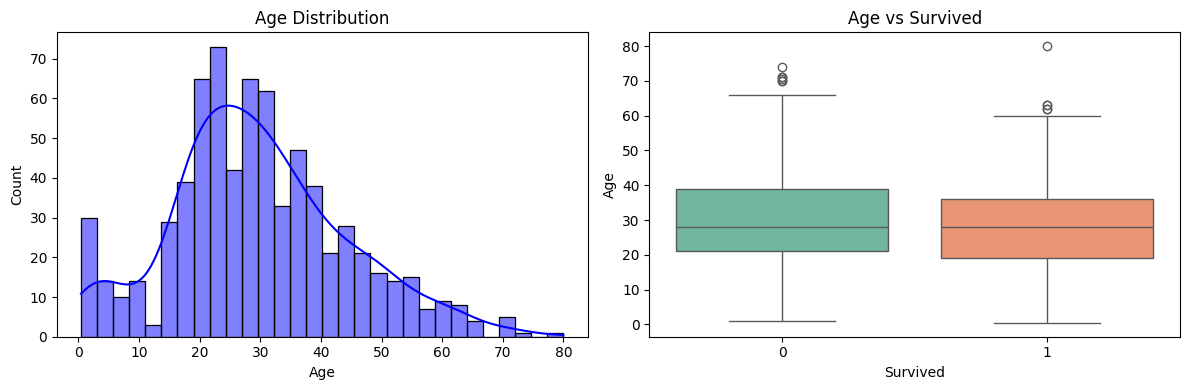

In [7]:
# Age distribution
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='blue')
plt.title('Age Distribution')

plt.subplot(1,2,2)
sns.boxplot(x='Survived', y='Age', data=df, palette='Set2')
plt.title('Age vs Survived')

plt.tight_layout()
plt.show()

C:\Users\jenef\AppData\Local\Temp\ipykernel_28992\3372389899.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette='Set1')


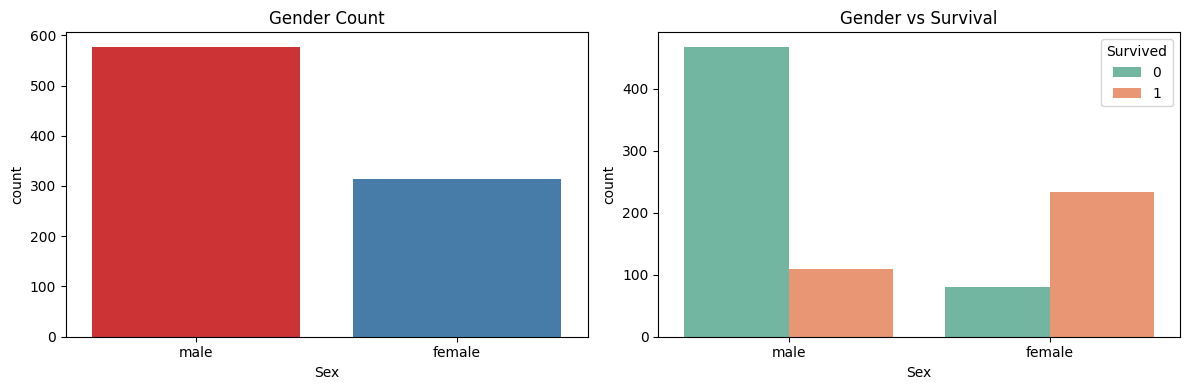

Survival Rate by Gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [8]:
# Gender vs Survival
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(x='Sex', data=df, palette='Set1')
plt.title('Gender Count')

plt.subplot(1,2,2)
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title('Gender vs Survival')

plt.tight_layout()
plt.show()

# Survival rate by gender
print("Survival Rate by Gender:")
print(df.groupby('Sex')['Survived'].mean() * 100)

C:\Users\jenef\AppData\Local\Temp\ipykernel_28992\4048402012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='Set1')


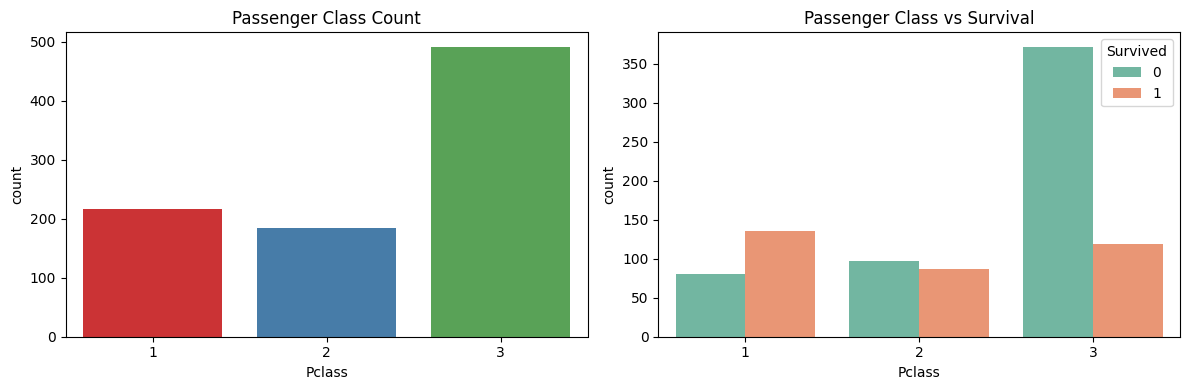

Survival Rate by Passenger Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [9]:
# Pclass vs Survival
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(x='Pclass', data=df, palette='Set1')
plt.title('Passenger Class Count')

plt.subplot(1,2,2)
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2')
plt.title('Passenger Class vs Survival')

plt.tight_layout()
plt.show()

# Survival rate by class
print("Survival Rate by Passenger Class:")
print(df.groupby('Pclass')['Survived'].mean() * 100)

C:\Users\jenef\AppData\Local\Temp\ipykernel_28992\2810124664.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, palette='Set2')


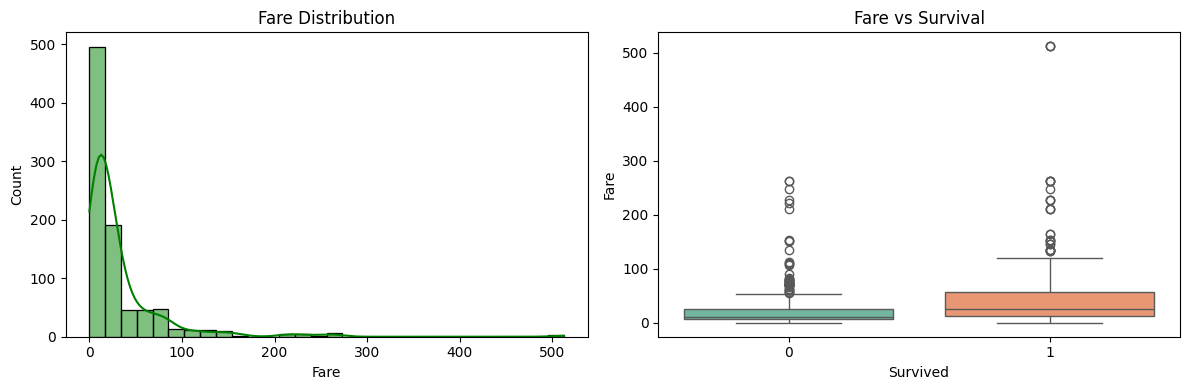

Average Fare by Passenger Class:
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [10]:
# Fare distribution
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['Fare'], bins=30, kde=True, color='green')
plt.title('Fare Distribution')

plt.subplot(1,2,2)
sns.boxplot(x='Survived', y='Fare', data=df, palette='Set2')
plt.title('Fare vs Survival')

plt.tight_layout()
plt.show()

# Average fare by class
print("Average Fare by Passenger Class:")
print(df.groupby('Pclass')['Fare'].mean())

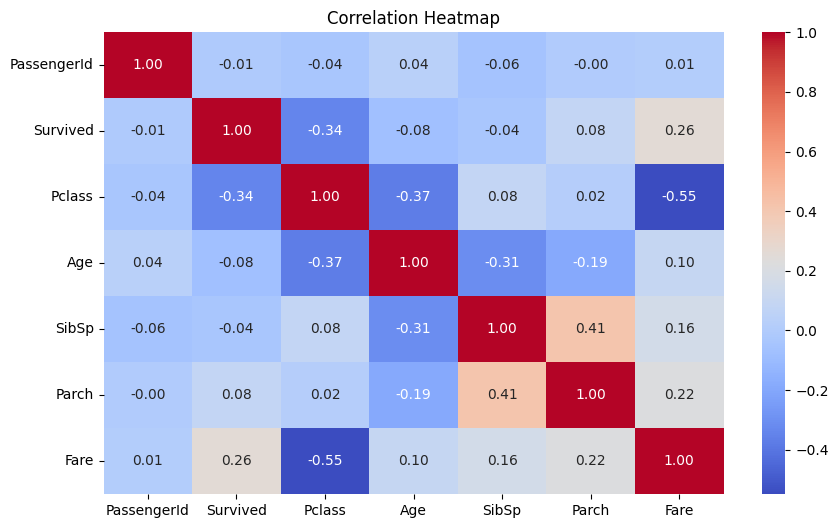

Key Findings:
1. Females had higher survival rate than males
2. 1st class passengers survived more than 2nd and 3rd class
3. Younger passengers had slightly higher survival rate
4. Higher fare passengers had better survival chances


In [11]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Key findings
print("Key Findings:")
print("1. Females had higher survival rate than males")
print("2. 1st class passengers survived more than 2nd and 3rd class")
print("3. Younger passengers had slightly higher survival rate")
print("4. Higher fare passengers had better survival chances")